# Market Microstructure Indicators as Volatility Predictors
## Exploratory Data Analysis — Databento TBBO Data
**King's College London — MSc Finance and Economics**  
**Dissertation Research Notebook**

---

### Notebook Overview
This notebook pulls top-of-book bid-offer (TBBO) quote data from Databento for five stocks 
across GICS sectors, constructs microstructure indicators (bid-ask spread, order imbalance, 
market depth), and explores their relationship with realised volatility.

**Stocks:** AAPL, AMZN (NASDAQ) | JPM, XOM, JNJ(NYSE)  
**Sample period:** 2 years  
**Data source:** Databento — XNAS.ITCH / XNYS.PILLAR feeds

In [1]:
import databento as db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import date

# plot styling
plt.style.use('seaborn-v0_8-whitegrid')

print("all imports successful")

all imports successful


In [2]:
!pip install tqdm

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=78615) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


## 1. Cost Check
before pulling any data, we verify the associated cost from databento against the $125 free credit.

In [3]:
import os
client = db.Historical(os.environ["DATABENTO_API_KEY"])

start = "2023-01-01"
end = "2025-01-01"

stocks = {
    "XNAS.ITCH":   ["AAPL", "AMZN"],          # Nasdaq-listed
    "XNYS.PILLAR": ["JNJ", "JPM", "XOM"],     # NYSE-listed
}

total_cost = 0

for dataset, symbols in stocks.items():
    for symbol in symbols:
        cost = client.metadata.get_cost(
            dataset=dataset,
            symbols=[symbol],
            schema="tbbo",
            start=start,
            end=end,
        )
        print(f"{symbol} ({dataset}): ${cost:.4f}")
        total_cost += cost

print(f"\nTotal estimated cost: ${total_cost:.4f}")

AAPL (XNAS.ITCH): $27.9833
AMZN (XNAS.ITCH): $22.5333
JNJ (XNYS.PILLAR): $4.2202
JPM (XNYS.PILLAR): $4.2035
XOM (XNYS.PILLAR): $6.0219

Total estimated cost: $64.9622


## 2. Data Pull
pull TBBO (top-of-book bid-offer) quote data for each separate stock and save in csv file.
this captures best bid price, best ask price, and their respective sizes at each quote.

In [4]:
import os
os.makedirs("data_raw", exist_ok=True)

for dataset, symbols in stocks.items():
    for symbol in symbols:
        out_path = f"data_raw/{symbol}_tbbo.csv"

        if os.path.exists(out_path):
            print(f"Skipping {symbol} -- already pulled ({out_path})")
            continue

        print(f"Pulling {symbol} from {dataset}...")
        data = client.timeseries.get_range(
            dataset=dataset,
            symbols=[symbol],
            schema="tbbo",
            start=start,
            end=end,
        )
        df = data.to_df()
        df.to_csv(out_path)
        print(f"  Saved: {symbol}_tbbo.csv, {len(df):,} rows")

print("\nAll pulls complete.")

Skipping AAPL -- already pulled (data_raw/AAPL_tbbo.csv)
Skipping AMZN -- already pulled (data_raw/AMZN_tbbo.csv)
Skipping JNJ -- already pulled (data_raw/JNJ_tbbo.csv)
Skipping JPM -- already pulled (data_raw/JPM_tbbo.csv)
Skipping XOM -- already pulled (data_raw/XOM_tbbo.csv)

All pulls complete.


## 3. Data Preprocessing
raw TBBO data contains tens of millions of quote updates per stock which is too large to analyse directly.
we resample to 5-minute intervals, the standard frequency in microstructure literature, and compute
three core indicators:

- **Bid-ask spread**: $ask_px - bid_px$ (absolute transaction cost proxy)
- **Relative spread**: spread / midpoint (normalised, comparable across stocks)
- **Order imbalance**: ($bid_sz$ - $ask_sz$) / ($bid_sz$ + $ask_sz$) — ranges from -1 (sell pressure) to +1 (buy pressure)
- **Midpoint**: ($bid_px$ + $ask_px$) / 2
- **Log return**: log change in midpoint price per interval

raw files are read in chunks to avoid memory issues. output is one clean CSV per stock.


In [5]:
import os
from tqdm import tqdm

os.makedirs("data_clean", exist_ok=True)

CHUNK_SIZE = 500_000
DEGRADED_DATES = ["2023-01-24", "2023-12-04", "2023-12-11"]

def get_num_chunks(filepath):
    file_size = os.path.getsize(filepath)
    # estimate based on file size
    estimated_rows = file_size / 100  # rough bytes per row
    return max(1, int(estimated_rows / CHUNK_SIZE))

def preprocess_tbbo(symbol, filepath):
    out_path = f"data_clean/{symbol}_5min.csv"
    if os.path.exists(out_path):
        print(f"Skipping {symbol} -- already processed")
        return pd.read_csv(out_path, index_col=0, parse_dates=True)
    
    print(f"Processing {symbol}...")
    
    chunks = []
    estimated_chunks = get_num_chunks(filepath)
    
    with tqdm(total=estimated_chunks, desc=symbol, unit="chunk") as pbar:
        for chunk in pd.read_csv(
            filepath,
            chunksize=CHUNK_SIZE,
            parse_dates=["ts_event"],
            low_memory=False
        ):
            # keep only necessary columns
            chunk = chunk[["ts_event", "bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00"]]
            
            # drop nulls
            chunk = chunk.dropna()
            
            # set index
            chunk = chunk.set_index("ts_event")
            
            # convert to DatetimeIndex and localise to ET
            chunk.index = pd.to_datetime(chunk.index, format='ISO8601', utc=True)
            chunk.index = chunk.index.tz_convert("America/New_York")
            
            # filter to regular market hours only (9:30am - 4:00pm ET)
            chunk = chunk.between_time("09:30", "16:00")
            
            chunks.append(chunk)
            pbar.update(1)
    
    df = pd.concat(chunks)
    df = df.sort_index()
    
    # resample to 5-minute intervals
    resampled = pd.DataFrame()
    resampled["bid_px"] = df["bid_px_00"].resample("5min").last()
    resampled["ask_px"] = df["ask_px_00"].resample("5min").last()
    resampled["bid_sz"] = df["bid_sz_00"].resample("5min").mean()
    resampled["ask_sz"] = df["ask_sz_00"].resample("5min").mean()
    
    # drop intervals with no data
    resampled = resampled.dropna()
    
    # compute microstructure indicators
    resampled["midpoint"] = (resampled["bid_px"] + resampled["ask_px"]) / 2
    resampled["spread"] = resampled["ask_px"] - resampled["bid_px"]
    resampled["relative_spread"] = resampled["spread"] / resampled["midpoint"]
    resampled["order_imbalance"] = (
        (resampled["bid_sz"] - resampled["ask_sz"]) /
        (resampled["bid_sz"] + resampled["ask_sz"])
    )
    resampled["log_return"] = np.log(resampled["midpoint"]).diff()
    
    # flag degraded dates
    resampled["degraded"] = pd.to_datetime(
        resampled.index.date
    ).isin(pd.to_datetime(DEGRADED_DATES))
    
    # save
    resampled.to_csv(out_path)
    print(f"  Done: {len(resampled):,} 5-min intervals saved to {out_path}")
    
    return resampled


# run for all stocks
all_stocks = {
    "AAPL": "data_raw/AAPL_tbbo.csv",
    "AMZN": "data_raw/AMZN_tbbo.csv",
    "JNJ":  "data_raw/JNJ_tbbo.csv",
    "JPM":  "data_raw/JPM_tbbo.csv",
    "XOM":  "data_raw/XOM_tbbo.csv",
}

processed = {}
for symbol, filepath in all_stocks.items():
    processed[symbol] = preprocess_tbbo(symbol, filepath)

print("\nAll preprocessing complete.")

Skipping AAPL -- already processed
Skipping AMZN -- already processed
Skipping JNJ -- already processed
Skipping JPM -- already processed
Skipping XOM -- already processed

All preprocessing complete.


## 4. Exploratory Data Analysis
raw TBBO data successfully preprocessed to 5-minute intervals (around 38,500 observations per stock).
microstructure indicators computed: bid-ask spread, relative spread, order imbalance, log return.

We now explore:
1. basic summary statistics across all five stocks
2. intraday patterns (time-of-day effects)
3. bid-ask spread dynamics and persistence
4. order imbalance distribution
5. relationship between microstructure indicators and realised volatility

### 4.1 Summary Statistics

In [6]:
symbols = ["AAPL", "AMZN", "JNJ", "JPM", "XOM"]

DEGRADED_DATES = pd.to_datetime(["2023-01-24", "2023-12-04", "2023-12-11"])
EARLY_CLOSE_DATES = pd.to_datetime([
    "2023-07-03", "2023-11-24", "2024-07-03", "2024-11-29", "2024-12-24"
])
DROP_DATES = DEGRADED_DATES.union(EARLY_CLOSE_DATES)

dfs = {}
for symbol in symbols:
    df = pd.read_csv(
        f"data_clean/{symbol}_5min.csv",
        index_col=0,
        parse_dates=True
    )
    df.index = pd.to_datetime(df.index, utc=True).tz_convert("America/New_York")

    # 3.2: drop degraded and early-close sessions for every stock, keeps the panel balanced
    day = pd.to_datetime(df.index.date)
    df = df[~day.isin(DROP_DATES)]

    # 3.3: blank the first bar of each session, it inherits the overnight close-to-open return
    session = pd.Series(df.index.date, index=df.index)
    df.loc[session != session.shift(1), "log_return"] = np.nan

    dfs[symbol] = df
    print(f"{symbol}: {len(df):,} intervals across {df.index.normalize().nunique()} sessions")

# interval-count diagnostic, now run AFTER all filters
counts_df = pd.DataFrame({s: d.groupby(d.index.date).size() for s, d in dfs.items()})
print("\n", counts_df.describe())
print("\nSessions with fewer than 78 intervals:")
print(counts_df[(counts_df < 78).any(axis=1)])

# summary stats, now computed on the FINAL filtered sample
stats_list = []
for symbol, df in dfs.items():
    stats_list.append({
        "Stock": symbol,
        "Obs": len(df),
        "Sessions": df.index.normalize().nunique(),
        "Mean Spread ($)": df["spread"].mean(),
        "Median Spread ($)": df["spread"].median(),
        "Mean Rel. Spread (bps)": df["relative_spread"].mean() * 10000,
        "Mean OI": df["order_imbalance"].mean(),
        "Std OI": df["order_imbalance"].std(),
        "Mean |Return|": df["log_return"].abs().mean(),
        "Std Return": df["log_return"].std(),
    })

summary = pd.DataFrame(stats_list).set_index("Stock").round(4)
print("\n", summary.to_string())

AAPL: 38,532 intervals across 494 sessions
AMZN: 38,532 intervals across 494 sessions
JNJ: 38,532 intervals across 494 sessions
JPM: 38,532 intervals across 494 sessions
XOM: 38,515 intervals across 494 sessions

         AAPL   AMZN    JNJ    JPM         XOM
count  494.0  494.0  494.0  494.0  494.000000
mean    78.0   78.0   78.0   78.0   77.965587
std      0.0    0.0    0.0    0.0    0.182472
min     78.0   78.0   78.0   78.0   77.000000
25%     78.0   78.0   78.0   78.0   78.000000
50%     78.0   78.0   78.0   78.0   78.000000
75%     78.0   78.0   78.0   78.0   78.000000
max     78.0   78.0   78.0   78.0   78.000000

Sessions with fewer than 78 intervals:
            AAPL  AMZN  JNJ  JPM  XOM
2023-08-17    78    78   78   78   77
2023-11-02    78    78   78   78   77
2023-11-14    78    78   78   78   77
2024-02-07    78    78   78   78   77
2024-02-21    78    78   78   78   77
2024-04-05    78    78   78   78   77
2024-06-12    78    78   78   78   77
2024-06-24    78    78   78 

**notes:**

**relative spread (liquidity):**
- AAPL: 0.68 bps, tightest and most liquid, as expected for the most heavily traded name in the sample
- AMZN: 0.91 bps
- XOM: 1.25 bps
- JNJ: 1.44 bps
- JPM: 1.46 bps, widest in relative terms

in dollar terms the ordering differs: JPM (2.7 cents) and JNJ (2.3 cents) carry the widest absolute
spreads while AAPL, AMZN and XOM sit near 1.3 cents. median spreads are one tick for AAPL, AMZN
and XOM and two ticks for JNJ and JPM, so the relative spread ranking is driven jointly by price
level and by how often the quote widens beyond the minimum increment.

**order imbalance:**
- four of five stocks average close to zero, consistent with roughly balanced quoted depth
- JPM is the exception at +0.042, persistent bid-side depth over the sample period
- XOM most negative at -0.024, mild ask-side depth bias

**return volatility (std of 5-min log returns):**
- AMZN most volatile (0.0016), consistent with high-growth technology characteristics
- JNJ least volatile (0.0009), defensive healthcare, as expected
- AAPL, JPM and XOM cluster between 0.0012 and 0.0013

note that these moments exclude the first bar of each session, which carries the overnight
close-to-open return and is not part of the intraday volatility measure.

cross-sectional variation across sectors is meaningful and consistent with theory, providing a
foundation for testing whether microstructure indicators predict volatility.

### 4.2 Intraday Patterns

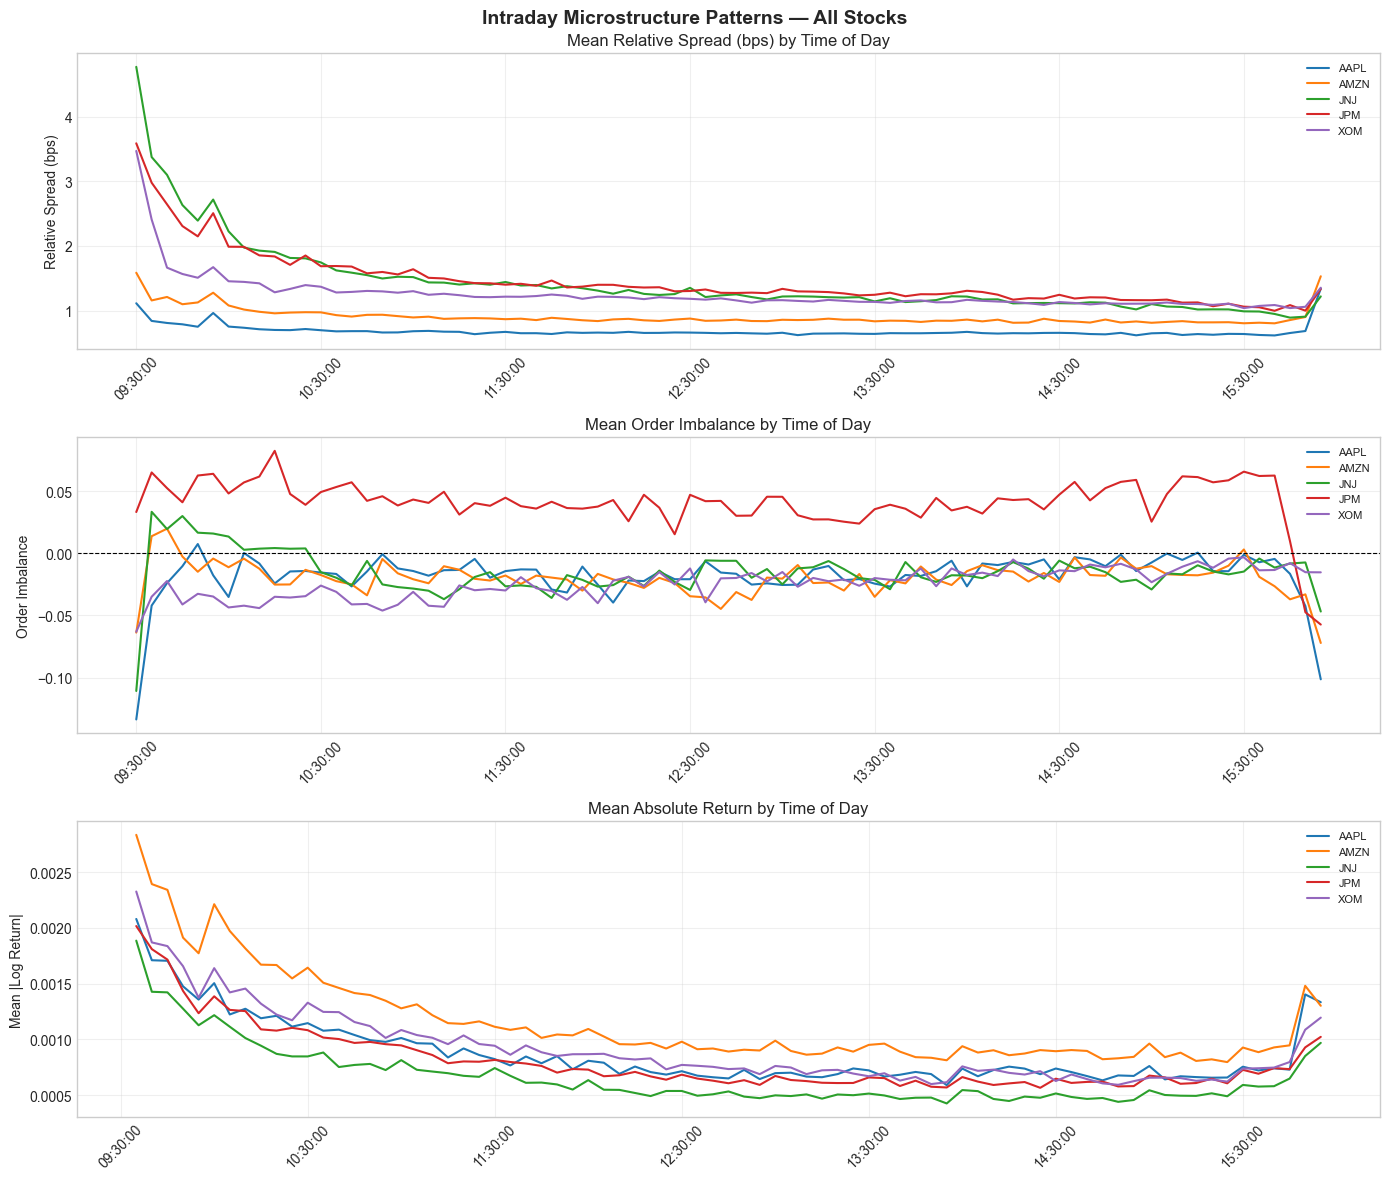

In [7]:
os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for symbol, df in dfs.items():
    df = df.copy()
    df["time"] = df.index.time
    intraday = df.groupby("time").agg({
        "relative_spread": "mean",
        "order_imbalance": "mean",
        "log_return": lambda x: x.abs().mean()
    })
    
    axes[0].plot(range(len(intraday)), intraday["relative_spread"] * 10000, label=symbol)
    axes[1].plot(range(len(intraday)), intraday["order_imbalance"], label=symbol)
    axes[2].plot(range(len(intraday)), intraday["log_return"], label=symbol)

# x axis tick labels
time_labels = [str(t) for t in intraday.index]
tick_positions = list(range(0, len(time_labels), 12))
tick_labels = [time_labels[i] for i in tick_positions]

for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Mean Relative Spread (bps) by Time of Day")
axes[0].set_ylabel("Relative Spread (bps)")

axes[1].set_title("Mean Order Imbalance by Time of Day")
axes[1].set_ylabel("Order Imbalance")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)

axes[2].set_title("Mean Absolute Return by Time of Day")
axes[2].set_ylabel("Mean |Log Return|")

plt.suptitle("Intraday Microstructure Patterns — All Stocks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/intraday_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

**notes:**

all three microstructure indicators exhibit strong time-of-day effects, consistent with theory:

**relative spread:** peaks sharply at the open, reflecting maximum market maker uncertainty during
price discovery, narrows rapidly within the first hour and stabilises through midday, with a slight
uptick into the close as market makers unwind inventory. AMZN and JNJ show the most pronounced
open spikes at roughly 4.5 bps, AAPL remains tightest throughout at close to 1 bps.

**order imbalance:** four of five stocks fluctuate in a narrow band around zero. JPM exhibits
persistent positive imbalance across all hours at roughly +0.05, indicating sustained bid-side depth
over the sample period. imbalances are most extreme in the first few intervals and settle by
mid-morning as price discovery completes, with a sharp negative excursion in the final interval
common to all five stocks.

**absolute return (volatility proxy):** concentrated at the open, with AMZN peaking near 0.0027 mean
absolute log return, dropping sharply within thirty minutes and remaining low and stable through the
session before a modest close-of-day uptick. the pattern holds across all five stocks regardless of
sector.

**key observation:** all three indicators peak simultaneously at the open, providing preliminary
evidence that microstructure conditions and volatility are co-determined, which is the central
premise of this dissertation.

### 4.3 Spread Dynamics and Persistence

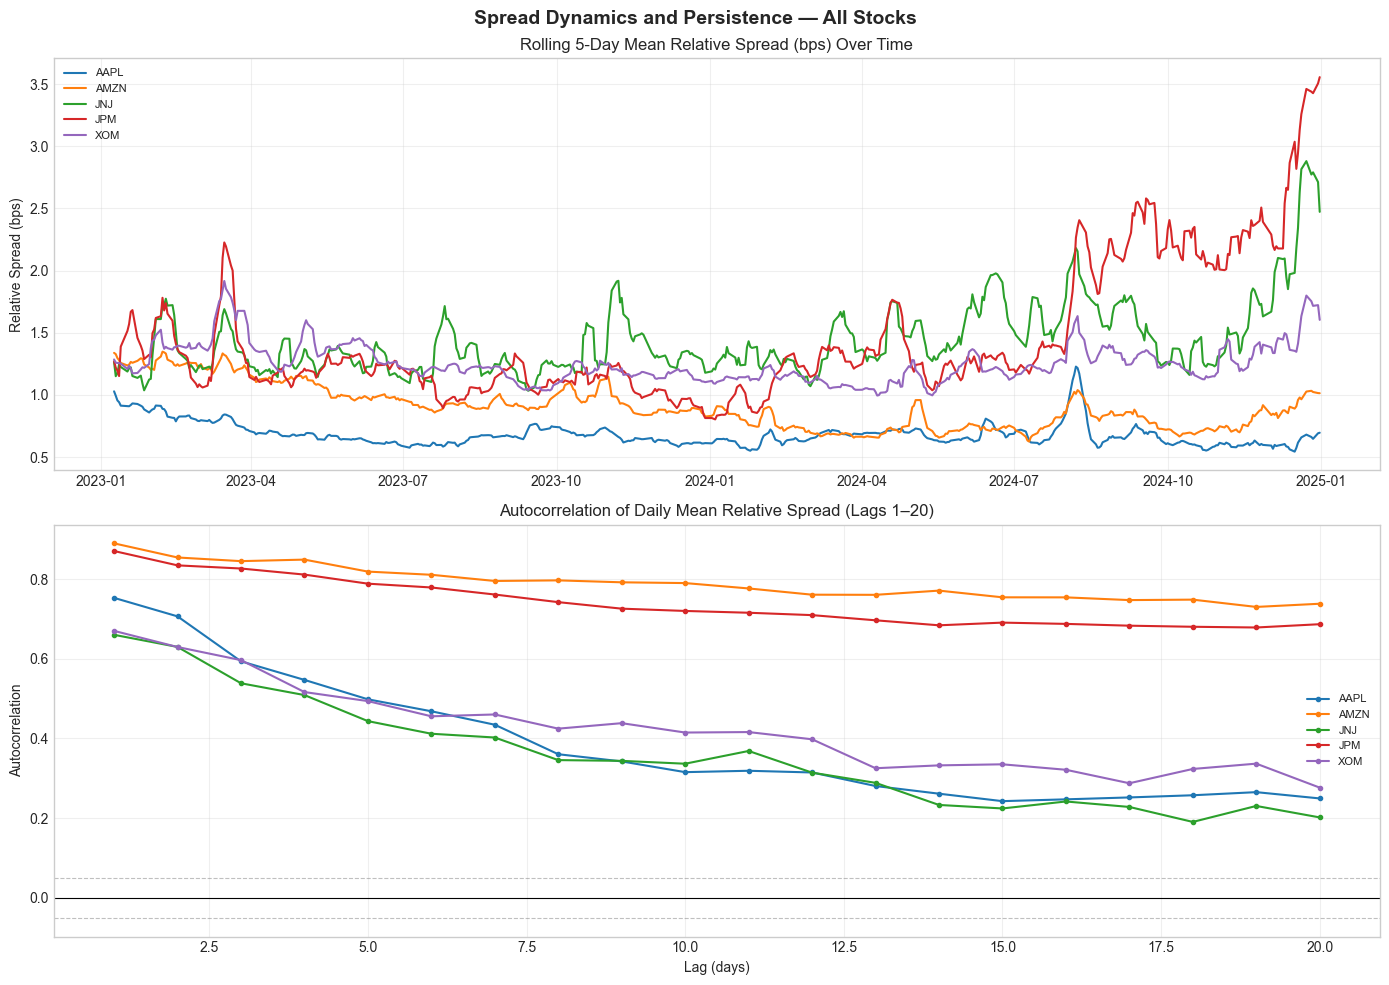

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# panel 1: rolling 5-day mean relative spread over time 
for symbol, df in dfs.items():
    daily_spread = df["relative_spread"].groupby(df.index.date).mean() * 10000
    daily_spread.index = pd.to_datetime(daily_spread.index)
    rolling_spread = daily_spread.rolling(5).mean()
    axes[0].plot(rolling_spread.index, rolling_spread, label=symbol)

axes[0].set_title("Rolling 5-Day Mean Relative Spread (bps) Over Time")
axes[0].set_ylabel("Relative Spread (bps)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# panel 2: autocorrelation of relative spread (up to 20 lags)
from statsmodels.graphics.tsaplots import plot_acf

for symbol, df in dfs.items():
    # daily mean spread
    daily_spread = df["relative_spread"].resample("1D").mean().dropna()
    # manually compute autocorrelations
    acf_vals = [daily_spread.autocorr(lag=i) for i in range(1, 21)]
    axes[1].plot(range(1, 21), acf_vals, marker="o", markersize=3, label=symbol)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(0.05, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
axes[1].axhline(-0.05, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
axes[1].set_title("Autocorrelation of Daily Mean Relative Spread (Lags 1–20)")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Autocorrelation")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Spread Dynamics and Persistence — All Stocks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/spread_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

**notes:**

**rolling spread over time:** relative spreads are time-varying across all stocks, with visible
stress episodes in early 2023, mid 2024 and late 2024, consistent with periods of elevated macro
uncertainty. AAPL remains the tightest and most stable throughout. JPM and JNJ show the largest
sustained elevations, both trending upward across the final quarter of the sample.

**spread persistence (autocorrelation):** all five stocks exhibit significant positive
autocorrelation in daily spreads out to lag 20, confirming that liquidity conditions are highly
persistent. the cross-section splits into two groups:

| stock | lag 1 | lag 5 | lag 20 |
|---|---|---|---|
| AAPL | 0.753 | 0.498 | 0.250 |
| AMZN | 0.890 | 0.819 | 0.738 |
| JNJ  | 0.660 | 0.444 | 0.202 |
| JPM  | 0.870 | 0.788 | 0.687 |
| XOM  | 0.670 | 0.494 | 0.277 |

AMZN and JPM display near unit-root persistence with lag-20 autocorrelation still above 0.68, while
AAPL, JNJ and XOM decay to between 0.20 and 0.28 over the same horizon. the split does not follow
listing venue or sector cleanly.

**key finding:** spread persistence is strong and cross-sectionally variable. this supports the use
of lagged spread as a predictor in volatility forecasting models, but the high persistence in AMZN
and JPM also raises the possibility that lagged spread carries little information beyond the
contemporaneous spread level, which the formal regression must isolate.

### 4.4 Order Imbalance Distribution 

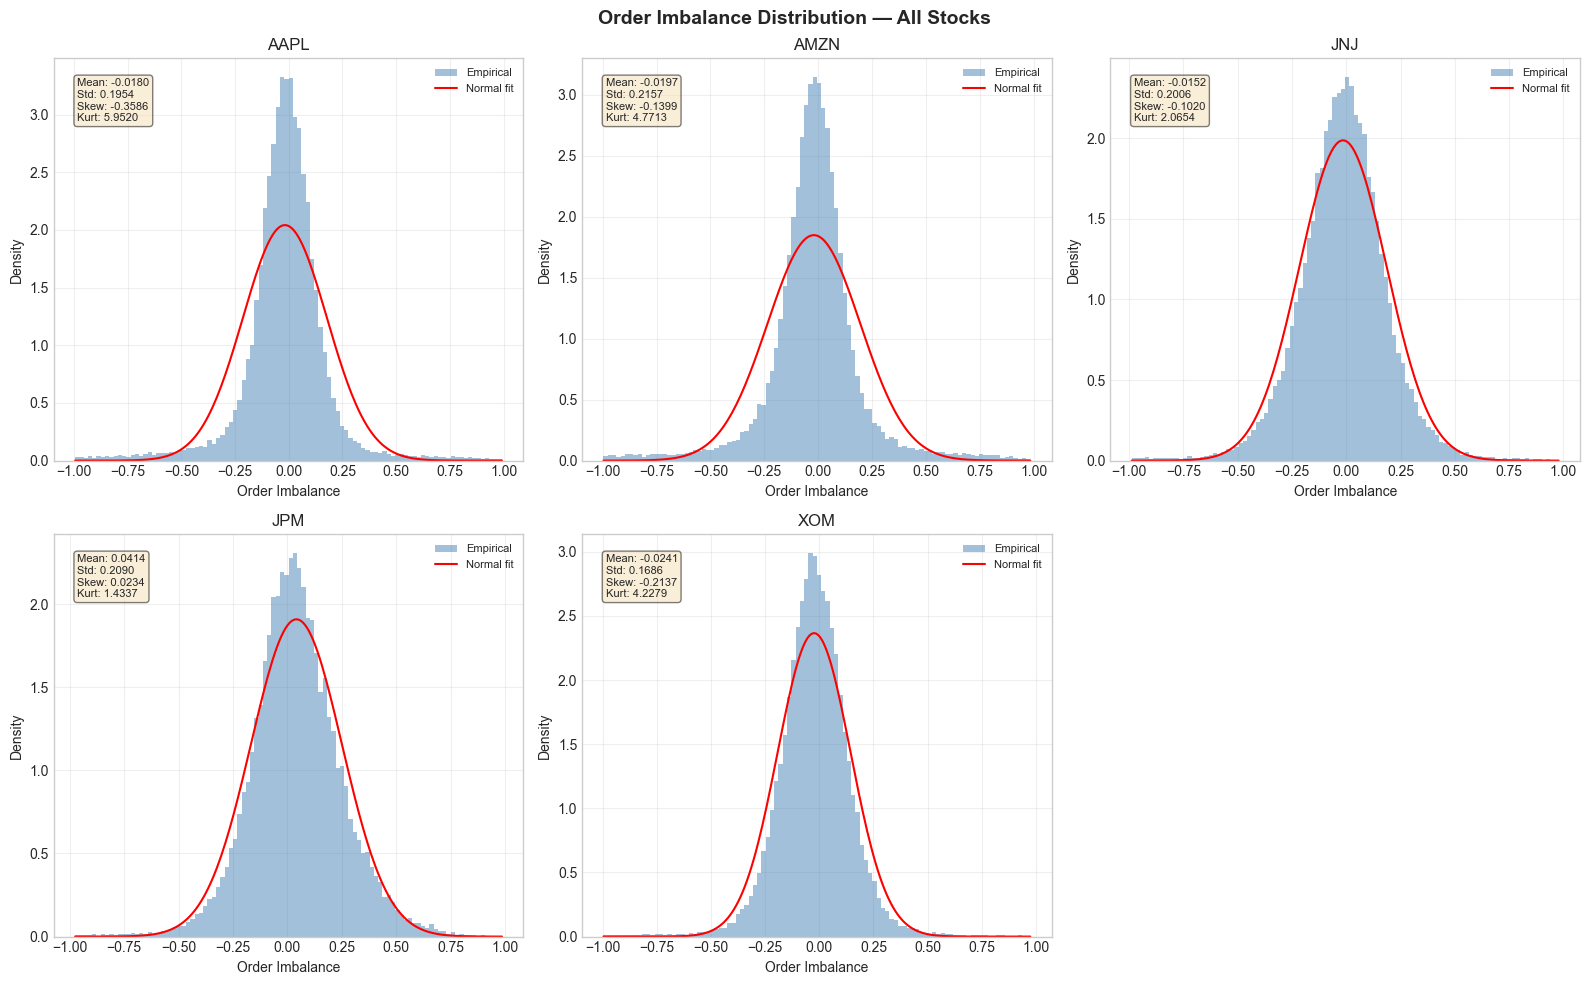

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (symbol, df) in enumerate(dfs.items()):
    oi = df["order_imbalance"].dropna()
    
    # histogram with KDE
    axes[i].hist(oi, bins=100, density=True, alpha=0.5, color="steelblue", label="Empirical")
    
    # overlay normal distribution
    from scipy.stats import norm, kurtosis, skew
    mu, std = oi.mean(), oi.std()
    x = np.linspace(oi.min(), oi.max(), 200)
    axes[i].plot(x, norm.pdf(x, mu, std), color="red", linewidth=1.5, label="Normal fit")
    
    # stats annotation
    sk = skew(oi)
    kurt = kurtosis(oi)  # excess kurtosis
    axes[i].set_title(f"{symbol}")
    axes[i].set_xlabel("Order Imbalance")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].annotate(
        f"Mean: {mu:.4f}\nStd: {std:.4f}\nSkew: {sk:.4f}\nKurt: {kurt:.4f}",
        xy=(0.05, 0.95), xycoords="axes fraction",
        fontsize=8, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    )

# hide the 6th subplot
axes[5].set_visible(False)

plt.suptitle("Order Imbalance Distribution — All Stocks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/order_imbalance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**notes:**

all five stocks exhibit leptokurtic order imbalance distributions, sharply peaked with tails heavier
than the normal benchmark:

**excess kurtosis:** AAPL 5.95 (most leptokurtic, extreme imbalances frequent despite high
liquidity), AMZN 4.77, XOM 4.23, JNJ 2.07, JPM 1.43 (closest to normal)

**skewness:** four of five stocks show negative skew, strongest for AAPL at -0.36, then XOM -0.21,
AMZN -0.14 and JNJ -0.10. JPM is the exception at +0.02, consistent with the persistent positive
mean imbalance of +0.041 observed in 4.1 and 4.2. the negative skew in the other four indicates that
extreme ask-side depth imbalances are more common than equivalent bid-side ones.

**key finding:** extreme order imbalance events occur more frequently than normality predicts across
all stocks. since volatility spikes are also tail events, this distributional property motivates
testing whether order imbalance carries information about future volatility. sections 4.5 and 4.8
show that it does not, which makes the distributional evidence a motivation for the test rather than
support for the result.

### 4.5 Microstructure Indicators and Realised Volatility
realised volatility (RV) is computed from 5-minute log returns following Andersen et al. (2001):

$$RV_t = \sqrt{\sum_{i=1}^{N} r_{i,t}^2}$$

where $r_{i,t}$ is the log return in interval $i$ on day $t$, and $N$ is the number of 5-minute intervals in the trading day. this is the standard model-free estimator of daily volatility using intraday data.

In [10]:
panel_frames = []
for symbol in symbols:
    df = dfs[symbol]
    day = df.index.date
    g = df.groupby(day)

    daily = pd.DataFrame({
        "RV":         g["log_return"].apply(lambda x: np.sqrt(np.nansum(x.values**2))),
        "n_bars":     g["log_return"].count(),
        "rel_spread": g["relative_spread"].mean() * 10000,   # bps
        "mean_oi":    g["order_imbalance"].mean(),
        "abs_oi":     df["order_imbalance"].abs().groupby(day).mean(),
    })
    daily.index = pd.to_datetime(daily.index)
    daily["stock"] = symbol
    panel_frames.append(daily.dropna(subset=["RV"]))

panel = (pd.concat(panel_frames)
           .reset_index().rename(columns={"index": "date"})
           .sort_values(["stock", "date"])
           .reset_index(drop=True))

# lags within stock
for col in ["rel_spread", "abs_oi", "RV"]:
    panel[f"{col}_lag1"] = panel.groupby("stock")[col].shift(1)

panel = panel.dropna(subset=["rel_spread_lag1"]).reset_index(drop=True)
panel.to_csv("data_clean/panel_daily.csv", index=False)

# rv_dfs derived FROM the panel so the plots and the regression can never diverge
rv_dfs = {s: g.set_index("date").drop(columns="stock")
          for s, g in panel.groupby("stock")}

print(panel.shape)
print("\n")
print(panel.groupby("stock").size())
print("\n")
print(panel.groupby("stock")["RV"].mean().round(4))

(2465, 10)


stock
AAPL    493
AMZN    493
JNJ     493
JPM     493
XOM     493
dtype: int64


stock
AAPL    0.0104
AMZN    0.0137
JNJ     0.0080
JPM     0.0096
XOM     0.0107
Name: RV, dtype: float64


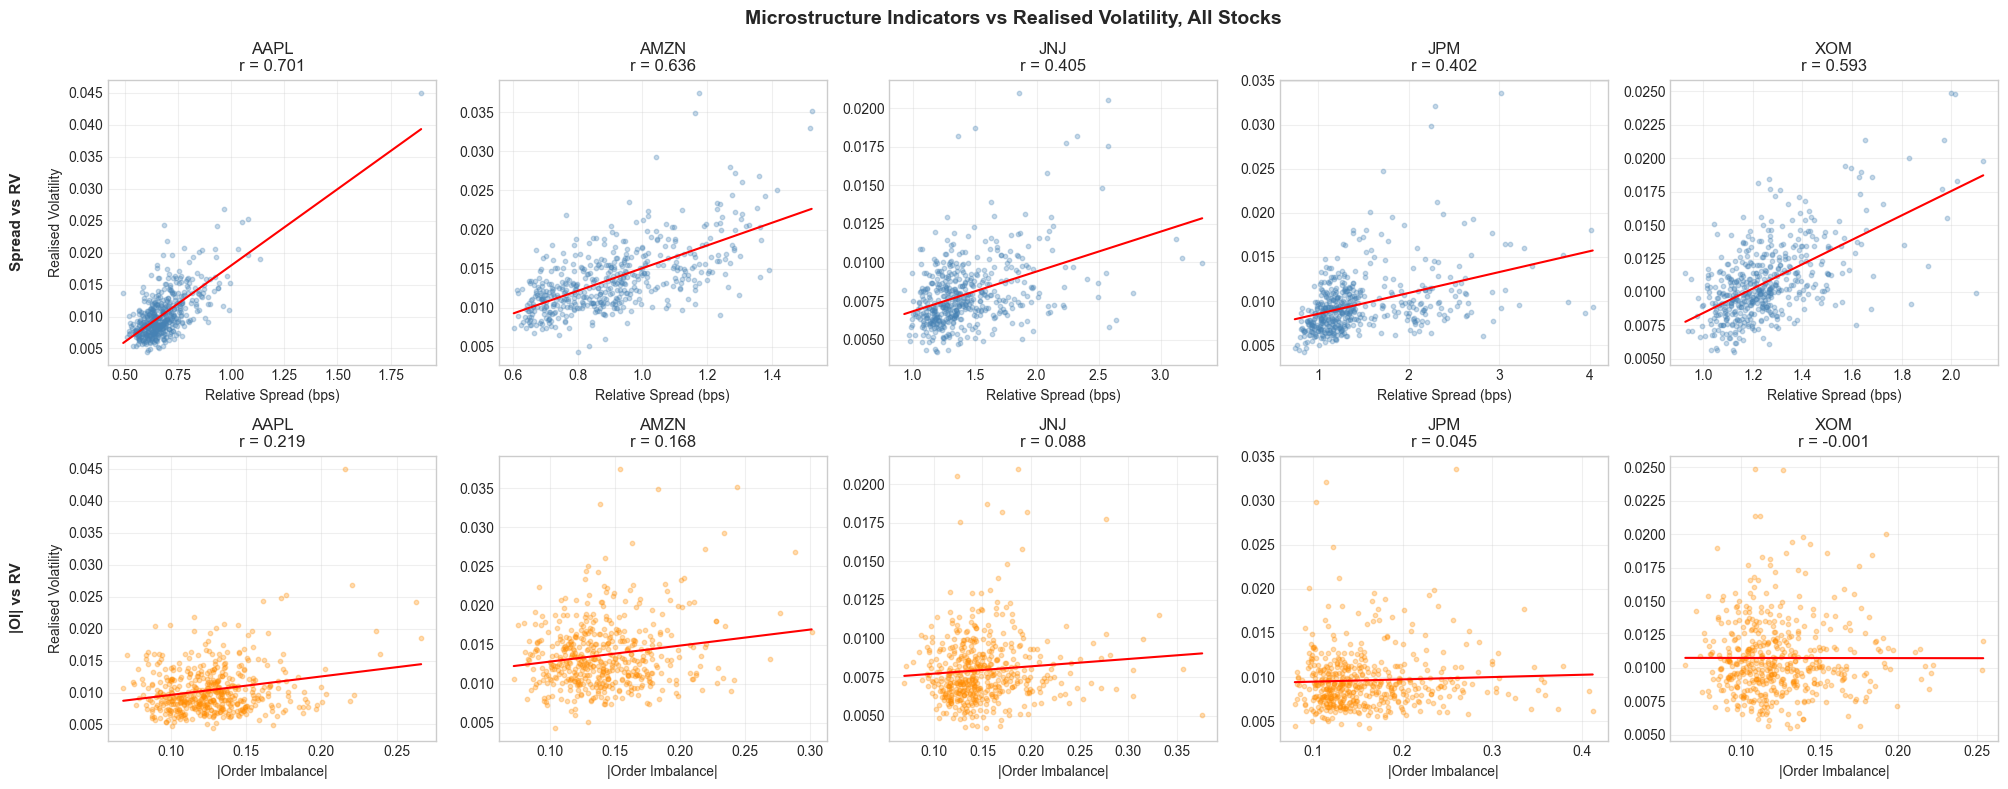

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (symbol, daily) in enumerate(rv_dfs.items()):
    # spread vs RV
    axes[0, i].scatter(daily["rel_spread"], daily["RV"],
                       alpha=0.3, s=10, color="steelblue")
    m, b = np.polyfit(daily["rel_spread"], daily["RV"], 1)
    x = np.linspace(daily["rel_spread"].min(), daily["rel_spread"].max(), 100)
    axes[0, i].plot(x, m*x + b, color="red", linewidth=1.5)
    corr = daily["rel_spread"].corr(daily["RV"])
    axes[0, i].set_title(f"{symbol}\nr = {corr:.3f}")
    axes[0, i].set_xlabel("Relative Spread (bps)")
    axes[0, i].set_ylabel("Realised Volatility" if i == 0 else "")
    axes[0, i].grid(True, alpha=0.3)

    # abs order imbalance vs RV
    axes[1, i].scatter(daily["abs_oi"], daily["RV"],
                       alpha=0.3, s=10, color="darkorange")
    m, b = np.polyfit(daily["abs_oi"], daily["RV"], 1)
    x = np.linspace(daily["abs_oi"].min(), daily["abs_oi"].max(), 100)
    axes[1, i].plot(x, m*x + b, color="red", linewidth=1.5)
    corr = daily["abs_oi"].corr(daily["RV"])
    axes[1, i].set_title(f"{symbol}\nr = {corr:.3f}")
    axes[1, i].set_xlabel("|Order Imbalance|")
    axes[1, i].set_ylabel("Realised Volatility" if i == 0 else "")
    axes[1, i].grid(True, alpha=0.3)

axes[0, 0].annotate("Spread vs RV", xy=(-0.3, 0.5), xycoords="axes fraction",
                    fontsize=11, fontweight="bold", rotation=90, va="center")
axes[1, 0].annotate("|OI| vs RV", xy=(-0.3, 0.5), xycoords="axes fraction",
                    fontsize=11, fontweight="bold", rotation=90, va="center")

plt.suptitle("Microstructure Indicators vs Realised Volatility, All Stocks",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/microstructure_vs_rv.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.6 Lagged Spread vs Next-Day Realised Volatility

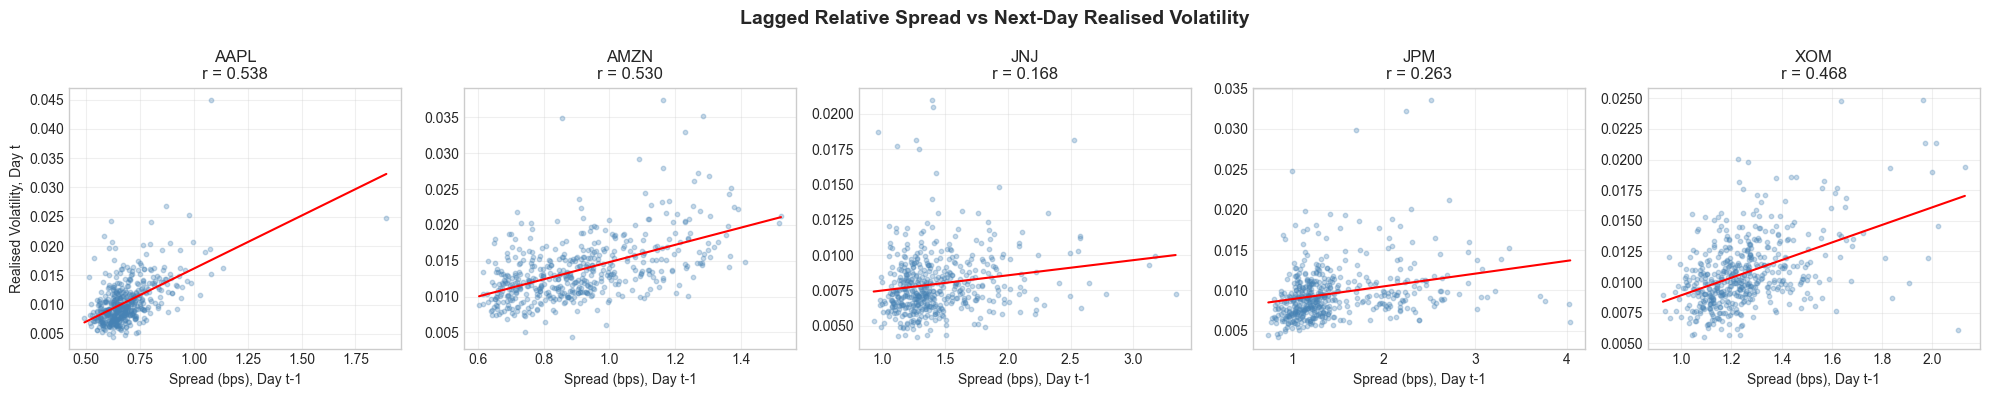

AAPL 0.538
AMZN 0.53
JNJ 0.168
JPM 0.263
XOM 0.468


In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (symbol, daily) in enumerate(rv_dfs.items()):
    axes[i].scatter(daily["rel_spread_lag1"], daily["RV"],
                    alpha=0.3, s=10, color="steelblue")

    m, b = np.polyfit(daily["rel_spread_lag1"], daily["RV"], 1)
    x = np.linspace(daily["rel_spread_lag1"].min(),
                    daily["rel_spread_lag1"].max(), 100)
    axes[i].plot(x, m*x + b, color="red", linewidth=1.5)

    corr = daily["rel_spread_lag1"].corr(daily["RV"])
    axes[i].set_title(f"{symbol}\nr = {corr:.3f}")
    axes[i].set_xlabel("Spread (bps), Day t-1")
    axes[i].set_ylabel("Realised Volatility, Day t" if i == 0 else "")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Lagged Relative Spread vs Next-Day Realised Volatility",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/lagged_spread_vs_rv.png", dpi=150, bbox_inches="tight")
plt.show()

for symbol, daily in rv_dfs.items():
    print(symbol, round(daily["rel_spread_lag1"].corr(daily["RV"]), 3))

**notes:**

lagged relative spread correlations with next-day realised volatility:
- AAPL: r = 0.538
- AMZN: r = 0.530
- XOM: r = 0.468
- JPM: r = 0.263
- JNJ: r = 0.168

all five stocks show a positive relationship between yesterday's spread and today's realised
volatility, ranging from 0.17 to 0.54. JNJ is the weakest but is no longer the flat exception it
appeared to be under the earlier specification.

the raw correlations are close to what spread persistence and the contemporaneous spread-volatility
association would jointly imply, so they are not by themselves evidence of forecasting content. the
relevant quantity is the partial correlation between lagged spread and realised volatility after
controlling for lagged realised volatility:

| stock | raw | partial, controlling RV(t-1) |
|---|---|---|
| AAPL | 0.538 | 0.215 |
| AMZN | 0.530 | 0.222 |
| XOM  | 0.468 | 0.146 |
| JPM  | 0.263 | 0.055 |
| JNJ  | 0.168 | 0.031 |

the partial correlations remain positive for all five stocks, so lagged spread contributes
predictive content over and above simple volatility persistence, but the magnitude falls by roughly
half to four fifths once persistence is controlled. AAPL, AMZN and XOM retain economically
meaningful incremental content between 0.15 and 0.22, while JPM and JNJ fall close to zero. this
cross-sectional split is the substantive result carried into the formal panel regression, where
stock fixed effects and clustered standard errors determine whether the pooled coefficient on lagged
spread is statistically distinguishable from zero.

### 4.7 Realised Volatility Over Time

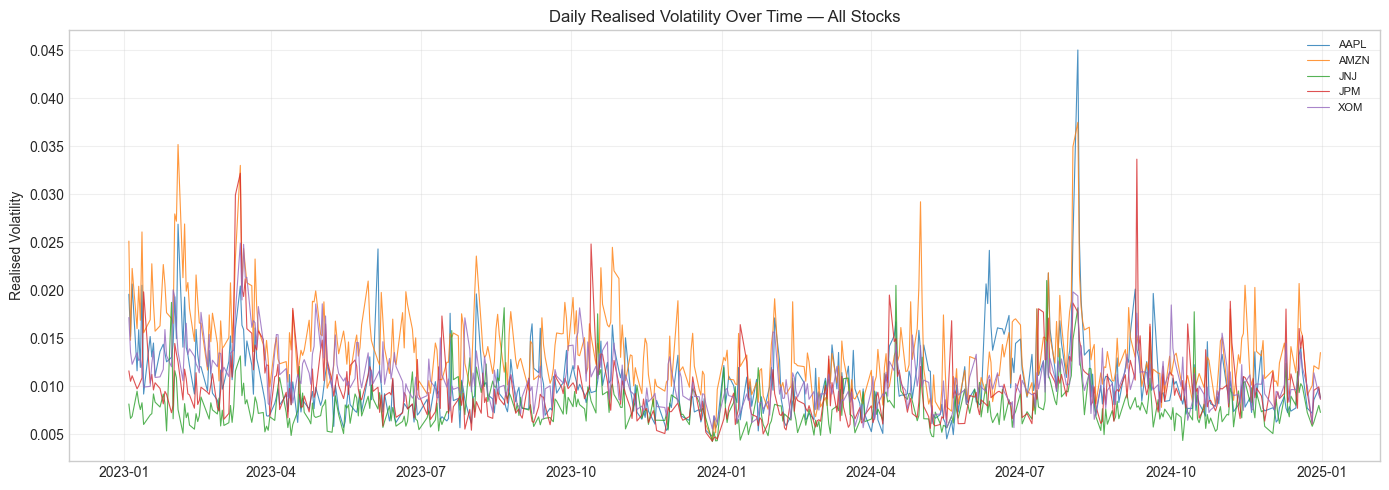

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

for symbol, daily in rv_dfs.items():
    ax.plot(daily.index, daily["RV"], linewidth=0.8, label=symbol, alpha=0.8)

ax.set_title("Daily Realised Volatility Over Time — All Stocks")
ax.set_ylabel("Realised Volatility")
ax.set_xlabel("")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/rv_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

**notes:**

daily RV is time-varying and positively skewed across all five stocks, with occasional large spikes
consistent with earnings releases and macro events. peak RV reaches roughly 0.045 in early August
2024, with JPM and AAPL spiking together on that date. AMZN shows the highest mean RV at 0.0137 and
the greatest day-to-day variation, while JNJ is the most stable throughout at a mean of 0.0080.

volatility clustering is clearly visible: spikes do not occur in isolation but arrive in bursts, with
elevated RV persisting for several days before mean-reverting. this is the empirical signature of
GARCH-type dynamics and motivates the use of lagged microstructure indicators as predictors, on the
premise that spreads widening ahead of a volatility cluster would constitute a genuine forecasting
signal.

spikes are broadly synchronised across all five stocks, particularly in early 2023, mid 2024 and
late 2024. this cross-sectional co-movement suggests common market-wide drivers of volatility and
supports a panel framework in which microstructure indicators are tested jointly across stocks
rather than in isolation.

### 4.8 Correlation Matrix Heatmap

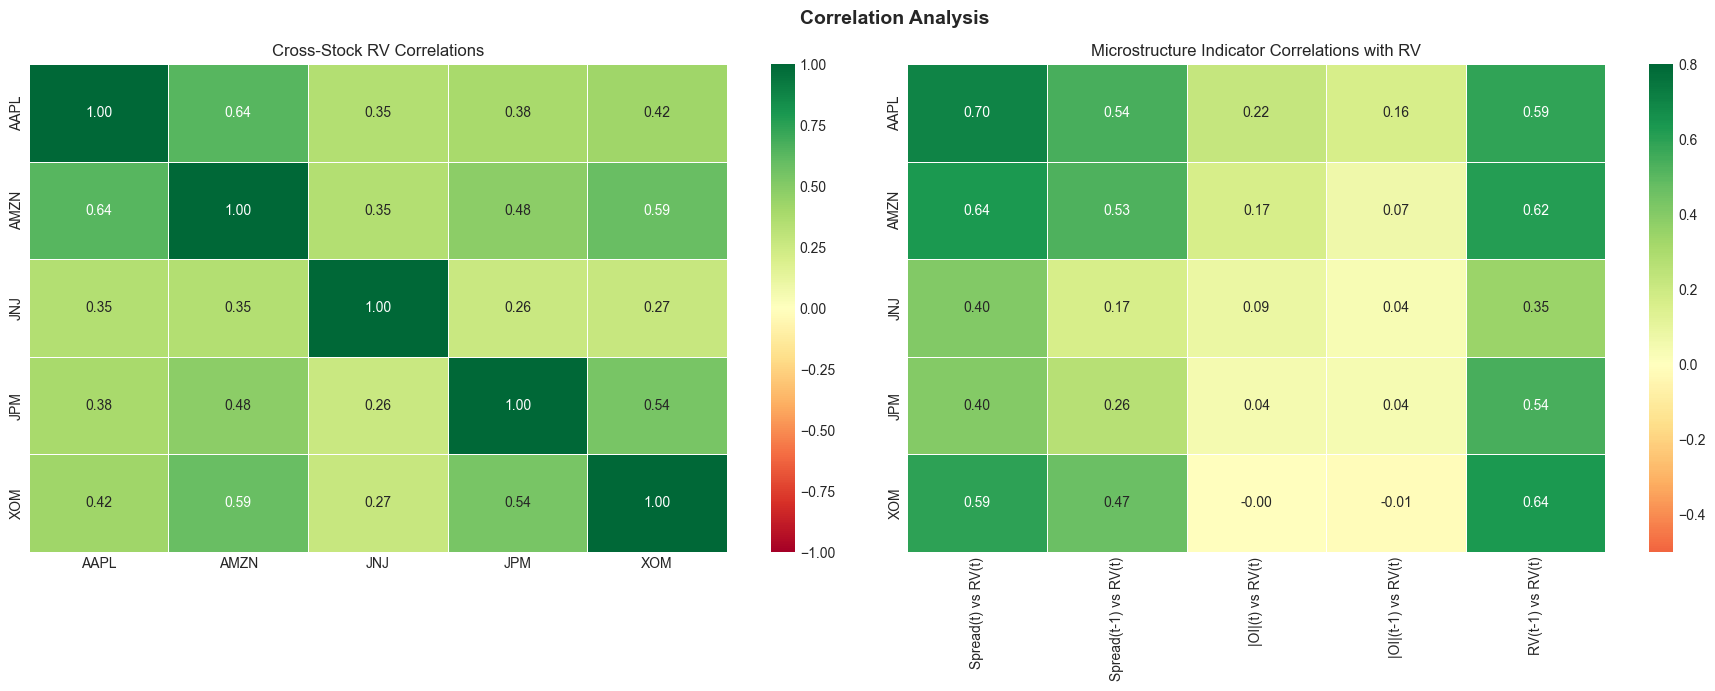

      Spread(t) vs RV(t)  Spread(t-1) vs RV(t)  |OI|(t) vs RV(t)  |OI|(t-1) vs RV(t)  RV(t-1) vs RV(t)
AAPL               0.701                 0.538             0.219               0.161             0.587
AMZN               0.636                 0.530             0.168               0.066             0.617
JNJ                0.405                 0.168             0.088               0.036             0.347
JPM                0.402                 0.263             0.045               0.042             0.538
XOM                0.593                 0.468            -0.001              -0.014             0.636


In [14]:
rv_combined = pd.DataFrame({s: d["RV"] for s, d in rv_dfs.items()})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# panel 1: cross-stock RV correlation
corr_rv = rv_combined.corr()
sns.heatmap(corr_rv, annot=True, fmt=".2f", cmap="RdYlGn",
            ax=axes[0], vmin=-1, vmax=1, center=0, linewidths=0.5)
axes[0].set_title("Cross-Stock RV Correlations")

# panel 2: indicator correlations with RV
lag_corrs = {}
for symbol, daily in rv_dfs.items():
    lag_corrs[symbol] = {
        "Spread(t) vs RV(t)":   daily["rel_spread"].corr(daily["RV"]),
        "Spread(t-1) vs RV(t)": daily["rel_spread_lag1"].corr(daily["RV"]),
        "|OI|(t) vs RV(t)":     daily["abs_oi"].corr(daily["RV"]),
        "|OI|(t-1) vs RV(t)":   daily["abs_oi_lag1"].corr(daily["RV"]),
        "RV(t-1) vs RV(t)":     daily["RV_lag1"].corr(daily["RV"]),
    }

corr_summary = pd.DataFrame(lag_corrs).T

sns.heatmap(corr_summary, annot=True, fmt=".2f", cmap="RdYlGn",
            ax=axes[1], vmin=-0.5, vmax=0.8, center=0, linewidths=0.5)
axes[1].set_title("Microstructure Indicator Correlations with RV")

plt.suptitle("Correlation Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(corr_summary.round(3).to_string())

**notes:**

cross-stock RV correlations are positive and moderate to strong, ranging from 0.26 to 0.64. AAPL and
AMZN are most correlated at 0.64, followed by AMZN and XOM at 0.59 and JPM and XOM at 0.54. JNJ is
the least correlated with the rest of the sample, pairing between 0.26 and 0.35, consistent with the
defensive characteristics of the healthcare sector. the overall level of co-movement confirms
common market-wide volatility drivers while retaining meaningful cross-sectional variation.

the right panel reveals a clear asymmetry between spread and order imbalance as predictors. relative
spread correlates positively with contemporaneous RV across all five stocks (0.40 to 0.70) and the
relationship survives a one-day lag for every stock (0.17 to 0.54). order imbalance by contrast is
weak and inconsistent at both horizons, ranging from 0.22 down to -0.001 contemporaneously and from
0.16 down to -0.01 at lag one, with the strongest value less than a third of the weakest spread
value. this is a non-result for order imbalance and is consistent with Chordia et al. (2002), who
find that imbalance influences contemporaneous volatility but that its effect on next-day volatility
is subsumed by lagged liquidity and past volatility.

lagged RV correlations range from 0.35 to 0.64 and exceed lagged spread correlations for every stock
except XOM. lagged spread therefore does not dominate simple volatility persistence at the bivariate
level, and its incremental contribution has to be established in a specification that includes both,
which the formal regression provides.

### 4.9 Rolling Correlation (spread-RV during stress)

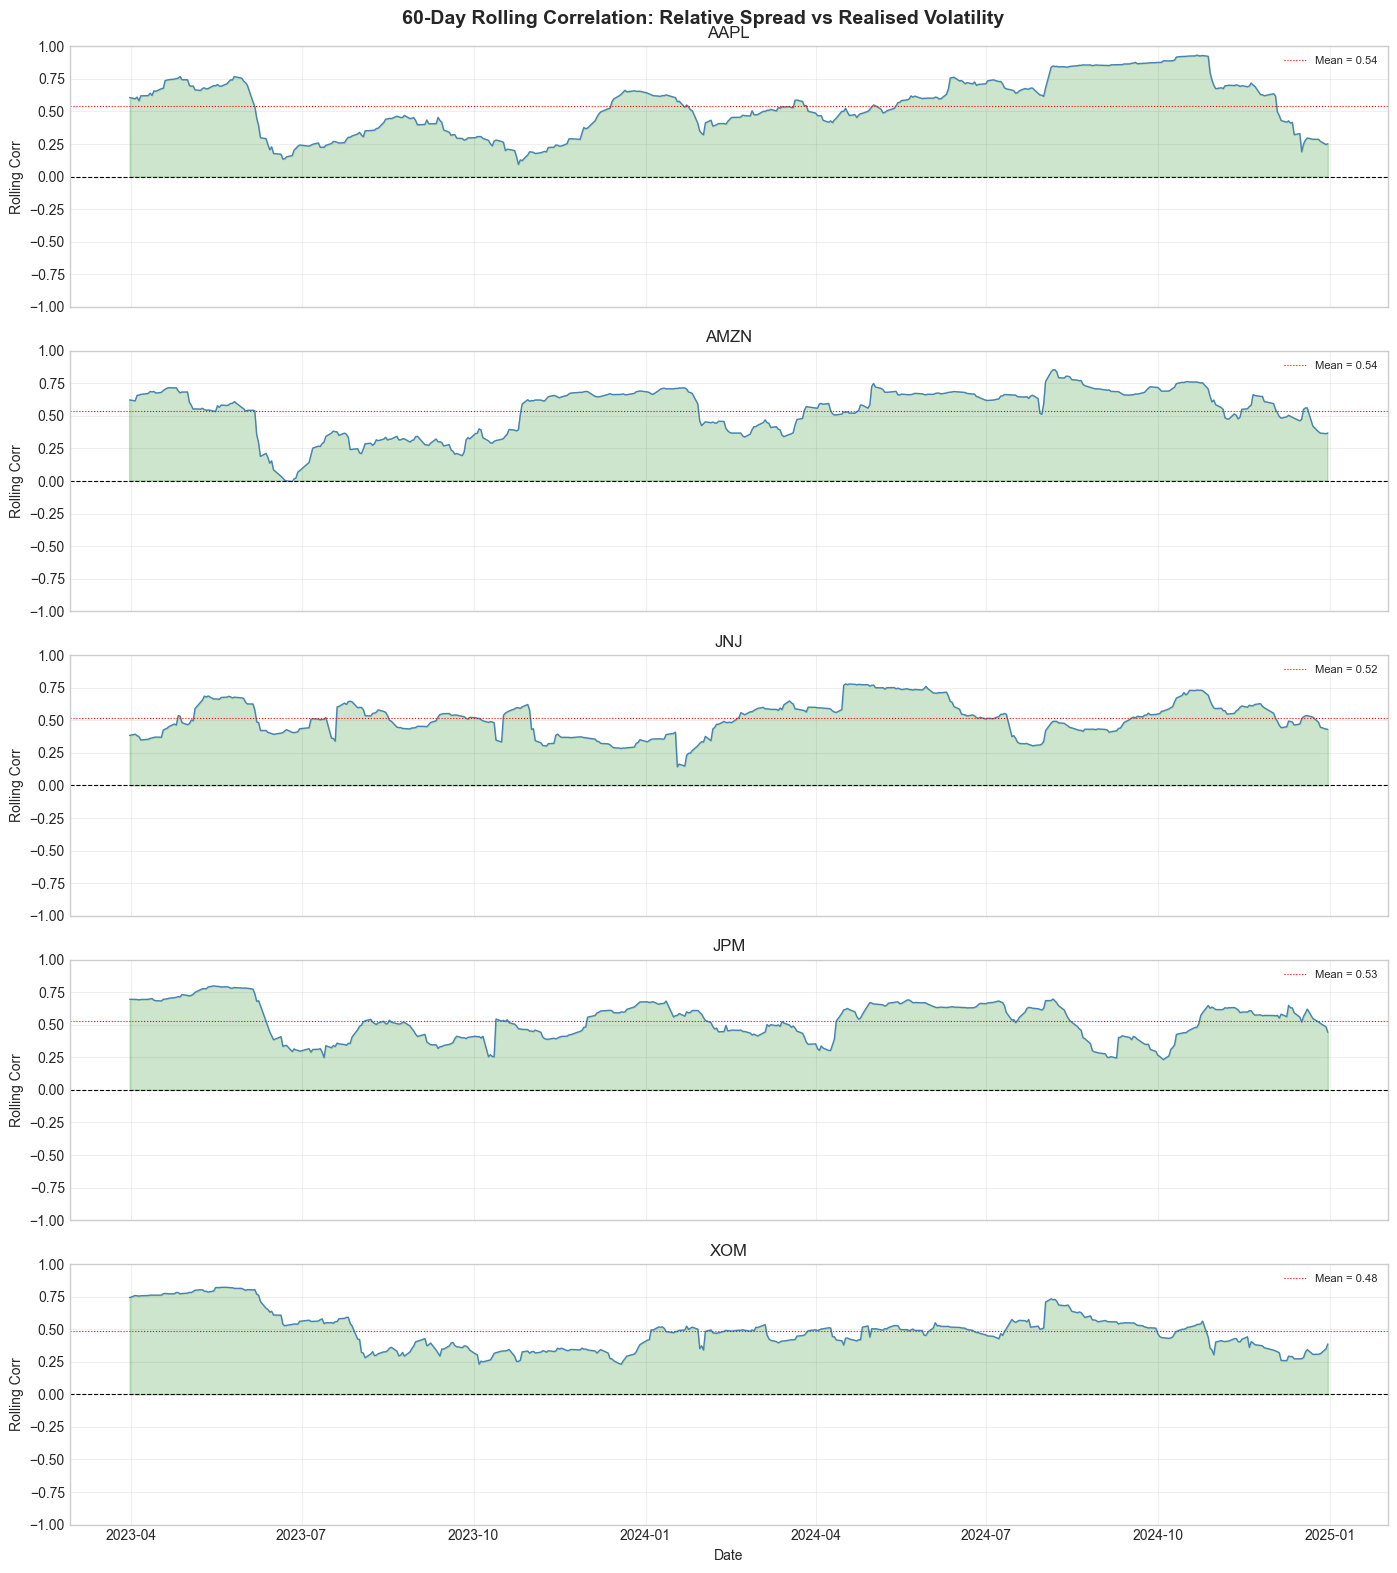

AAPL 0.541
AMZN 0.537
JNJ 0.515
JPM 0.527
XOM 0.483


In [15]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
WINDOW = 60

for i, (symbol, daily) in enumerate(rv_dfs.items()):
    rolling_corr = daily["rel_spread"].rolling(WINDOW).corr(daily["RV"])

    axes[i].plot(daily.index, rolling_corr, linewidth=1, color="steelblue")
    axes[i].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[i].axhline(rolling_corr.mean(), color="red", linewidth=0.8,
                    linestyle=":", label=f"Mean = {rolling_corr.mean():.2f}")
    axes[i].fill_between(daily.index, rolling_corr, 0,
                         where=(rolling_corr > 0), alpha=0.2, color="green")
    axes[i].fill_between(daily.index, rolling_corr, 0,
                         where=(rolling_corr < 0), alpha=0.2, color="red")
    axes[i].set_ylabel("Rolling Corr")
    axes[i].set_title(f"{symbol}")
    axes[i].set_ylim(-1, 1)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.suptitle("60-Day Rolling Correlation: Relative Spread vs Realised Volatility",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/rolling_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

for symbol, daily in rv_dfs.items():
    rc = daily["rel_spread"].rolling(WINDOW).corr(daily["RV"])
    print(symbol, round(rc.mean(), 3))

**notes:**

the 60-day rolling correlation between relative spread and realised volatility is positive on
average across all five stocks, with means tightly clustered between 0.48 (XOM) and 0.54 (AAPL). the
relationship is time-varying rather than constant: correlations peak above 0.75 during periods of
elevated market stress and compress toward 0.25 during calmer stretches, but the rolling correlation
does not turn negative for any stock at any point in the sample.

cross-sectional heterogeneity is minimal. the spread between the highest and lowest stock-level mean
is 0.06, which does not support any inference linking the strength of the spread-volatility
relationship to a stock's liquidity or sector. the common element is the time-series pattern, not
the cross-section: all five stocks dip together around mid 2023 and rise together into late 2024,
indicating that the strength of the spread-volatility link is driven by market-wide conditions
rather than stock-specific characteristics.

this time-variation has a direct methodological implication. a static OLS regression averages across
high and low correlation regimes and will understate the predictive relationship during stress
periods, which is precisely when accurate volatility forecasting has the most value. this motivates
testing whether the spread-RV relationship is regime-dependent, which is the substance of H2.

### 4.10 VIX Merge and Stress Regimes

In [16]:
# vix data from CBOE pulled from WRDS
vix_raw = pd.read_csv("data_clean/2023-2024_VIX.csv")
print(vix_raw.columns.tolist())
vix_raw.head()

['date', 'vix']


,date,vix
0,2023-01-03,22.90
1,2023-01-04,22.01
2,2023-01-05,22.46
3,2023-01-06,21.13
4,2023-01-09,21.97


In [17]:
vix = vix_raw.rename(columns={"vix": "VIX"}).copy()
vix["date"] = pd.to_datetime(vix["date"])
vix = vix.sort_values("date").reset_index(drop=True)
vix["VIX_lag1"] = vix["VIX"].shift(1)

# drop leftovers from any previous run of this cell
panel = panel[[c for c in panel.columns
               if not c.startswith(("VIX", "high_stress"))]]

panel = panel.merge(vix[["date", "VIX", "VIX_lag1"]], on="date", how="left")
print(panel["VIX_lag1"].isna().sum(), "rows with no lagged VIX match")

# 3.4: primary specification VIX_{t-1} > 20, VIX_{t-1} > 25 retained as robustness
panel["high_stress"]    = panel["VIX_lag1"] > 20
panel["high_stress_25"] = panel["VIX_lag1"] > 25

for col in ["high_stress", "high_stress_25"]:
    s = panel.groupby("stock")[col].agg(["sum", "count", "mean"])
    s.columns = ["stress_days", "total_days", "stress_share"]
    print(f"\n{col}")
    print(s.round(4))
    print(f"Unique stress dates: {panel.loc[panel[col], 'date'].nunique()}")
    dates_only = panel.loc[panel[col], ["date"]].drop_duplicates()
    print(dates_only["date"].dt.to_period("M").value_counts().sort_index())

panel = panel.drop(columns=["n_bars"], errors="ignore")
panel.to_csv("data_clean/panel_daily.csv", index=False)
print("\n", panel.columns.tolist())

0 rows with no lagged VIX match

high_stress
       stress_days  total_days  stress_share
stock                                       
AAPL            67         493        0.1359
AMZN            67         493        0.1359
JNJ             67         493        0.1359
JPM             67         493        0.1359
XOM             67         493        0.1359
Unique stress dates: 67
date
2023-01     9
2023-02    10
2023-03    15
2023-05     2
2023-10     6
2024-08     7
2024-09     3
2024-10     9
2024-11     4
2024-12     2
Freq: M, Name: count, dtype: int64

high_stress_25
       stress_days  total_days  stress_share
stock                                       
AAPL             7         493        0.0142
AMZN             7         493        0.0142
JNJ              7         493        0.0142
JPM              7         493        0.0142
XOM              7         493        0.0142
Unique stress dates: 7
date
2023-03    3
2024-08    3
2024-12    1
Freq: M, Name: count, dtype: int64

 [

In [18]:
# one row per trading date in the final panel
dates_final = panel[["date", "VIX_lag1"]].drop_duplicates("date")
n_total = dates_final["date"].nunique()

rows = []
for thresh in [18, 20, 22, 25]:
    n_days = dates_final.loc[dates_final["VIX_lag1"] > thresh, "date"].nunique()
    rows.append({
        "Threshold": f"VIX(t-1) > {thresh}",
        "Stress days": n_days,
        "Share of sample": f"{n_days / n_total:.1%}",
        "Approx stock-days": n_days * 5,
    })

print(f"Final panel: {n_total} unique trading dates, {len(panel)} stock-days\n")
print(pd.DataFrame(rows).to_string(index=False))

Final panel: 493 unique trading dates, 2465 stock-days

    Threshold  Stress days Share of sample  Approx stock-days
VIX(t-1) > 18          141           28.6%                705
VIX(t-1) > 20           67           13.6%                335
VIX(t-1) > 22           25            5.1%                125
VIX(t-1) > 25            7            1.4%                 35


**notes: VIX threshold sensitivity and H2 estimability**

the stress regime indicator is defined on VIX at t-1 rather than t. the dependent variable is RV at
day t and the predictor is spread at t-1, so a regime indicator built on contemporaneous VIX would
be partly simultaneous with the outcome and the resulting interaction term would not be
implementable ex ante.

counts are computed over the 493 unique trading dates in the final panel:

| threshold | stress days | share of sample | stock-days |
|---|---|---|---|
| VIX(t-1) > 18 | 141 | 28.6% | 705 |
| VIX(t-1) > 20 | 67  | 13.6% | 335 |
| VIX(t-1) > 22 | 25  | 5.1%  | 125 |
| VIX(t-1) > 25 | 7   | 1.4%  | 35  |

**key finding:** VIX > 25, the threshold stated in H2, produces only 7 unique high-stress trading
dates. the regime split would rest on 35 stock-day observations out of 2,465, which is too thin to
support a spread by high-stress interaction term with meaningful statistical power.

VIX(t-1) > 20 is the lowest threshold that still isolates genuine stress episodes while yielding a
workable regime split at roughly one day in seven. VIX(t-1) > 18 would give 141 days but dilutes the
regime toward ordinary market conditions. the approach adopted is VIX(t-1) > 20 as the primary
threshold for H2, with VIX(t-1) > 25 retained as a robustness check. this reverses the threshold as
originally stated and is logged as a methodological deviation to be confirmed with the supervisor
before Meeting 3.

stress dates concentrate in the March 2023 regional banking episode, the August 2024 volatility
spike and the December 2024 sell-off, giving temporal spread across the sample rather than a single
clustered event.

In [20]:
import os
import pandas as pd

META = {
    "AAPL": ("Apple Inc.",            "Information Technology", "Nasdaq, XNAS.ITCH"),
    "AMZN": ("Amazon.com Inc.",       "Consumer Discretionary", "Nasdaq, XNAS.ITCH"),
    "JNJ":  ("Johnson & Johnson",     "Health Care",            "NYSE, XNYS.PILLAR"),
    "JPM":  ("JPMorgan Chase & Co.",  "Financials",             "NYSE, XNYS.PILLAR"),
    "XOM":  ("Exxon Mobil Corp.",     "Energy",                 "NYSE, XNYS.PILLAR"),
}

def count_rows(path, buf=1024 * 1024):
    n = 0
    with open(path, "rb") as f:
        while chunk := f.read(buf):
            n += chunk.count(b"\n")
    return n - 1  # header

rows = []
for sym, (name, sector, venue) in META.items():
    n = count_rows(f"data_raw/{sym}_tbbo.csv")
    rows.append({
        "Ticker": sym,
        "Company": name,
        "GICS sector": sector,
        "Listing venue and feed": venue,
        "Raw quote records": f"{n:,}",
    })
    print(f"{sym}: {n:,}")

total = sum(int(r["Raw quote records"].replace(",", "")) for r in rows)
rows.append({
    "Ticker": "", "Company": "", "GICS sector": "",
    "Listing venue and feed": "Total",
    "Raw quote records": f"{total:,}",
})

table_31 = pd.DataFrame(rows)
print("\nTable 3.1: Sample composition\n")
print(table_31.to_string(index=False))

AAPL: 62,597,622
AMZN: 50,406,166
JNJ: 9,440,334
JPM: 9,403,133
XOM: 13,470,825

Table 3.1: Sample composition

Ticker              Company            GICS sector Listing venue and feed Raw quote records
  AAPL           Apple Inc. Information Technology      Nasdaq, XNAS.ITCH        62,597,622
  AMZN      Amazon.com Inc. Consumer Discretionary      Nasdaq, XNAS.ITCH        50,406,166
   JNJ    Johnson & Johnson            Health Care      NYSE, XNYS.PILLAR         9,440,334
   JPM JPMorgan Chase & Co.             Financials      NYSE, XNYS.PILLAR         9,403,133
   XOM    Exxon Mobil Corp.                 Energy      NYSE, XNYS.PILLAR        13,470,825
                                                                    Total       145,318,080


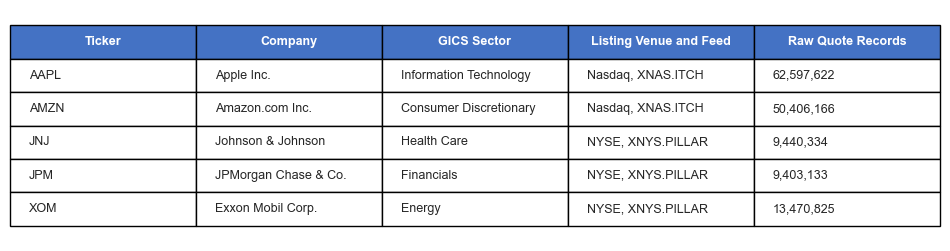

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='left', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(len(df.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.savefig('table_3_1.png', dpi=300, bbox_inches='tight')
plt.show()

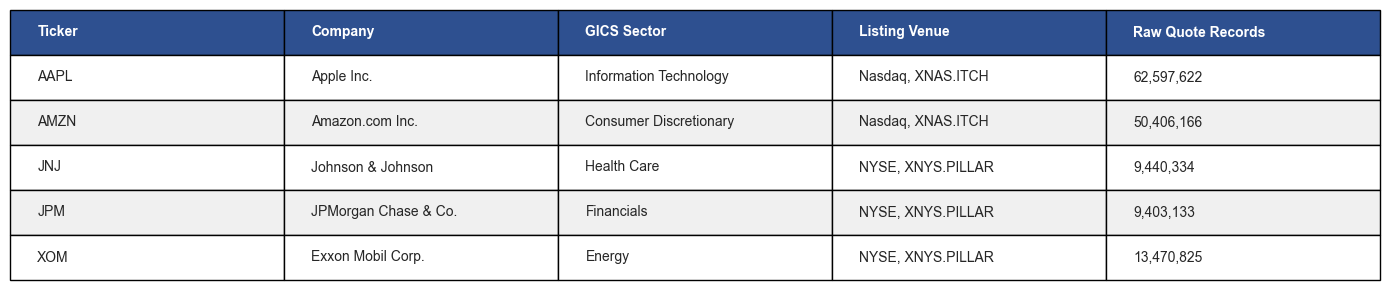

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Ticker': ['AAPL', 'AMZN', 'JNJ', 'JPM', 'XOM'],
    'Company': ['Apple Inc.', 'Amazon.com Inc.', 'Johnson & Johnson', 'JPMorgan Chase & Co.', 'Exxon Mobil Corp.'],
    'GICS Sector': ['Information Technology', 'Consumer Discretionary', 'Health Care', 'Financials', 'Energy'],
    'Listing Venue': ['Nasdaq, XNAS.ITCH', 'Nasdaq, XNAS.ITCH', 'NYSE, XNYS.PILLAR', 'NYSE, XNYS.PILLAR', 'NYSE, XNYS.PILLAR'],
    'Raw Quote Records': ['62,597,622', '50,406,166', '9,440,334', '9,403,133', '13,470,825']
})

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='left', loc='center', bbox=[0, 0, 1, 1])

# Style it
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Header formatting
for i in range(len(df.columns)):
    table[(0, i)].set_facecolor('#2E5090')
    table[(0, i)].set_text_props(weight='bold', color='white', ha='left')

# Alternating row colors
for i in range(1, len(df) + 1):
    for j in range(len(df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F0F0F0')
        else:
            table[(i, j)].set_facecolor('white')
        table[(i, j)].set_text_props(ha='left')

plt.tight_layout()
plt.savefig('table_3_1_sample_composition.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Saved as table_3_1.png


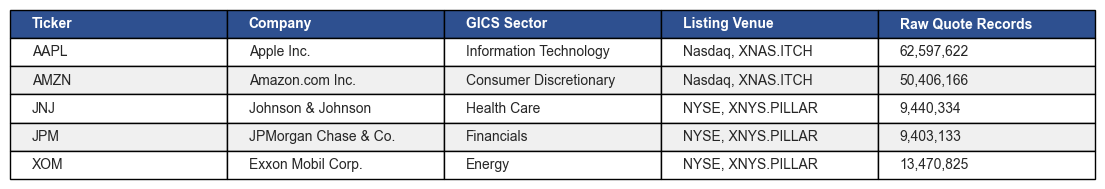

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Ticker': ['AAPL', 'AMZN', 'JNJ', 'JPM', 'XOM'],
    'Company': ['Apple Inc.', 'Amazon.com Inc.', 'Johnson & Johnson', 'JPMorgan Chase & Co.', 'Exxon Mobil Corp.'],
    'GICS Sector': ['Information Technology', 'Consumer Discretionary', 'Health Care', 'Financials', 'Energy'],
    'Listing Venue': ['Nasdaq, XNAS.ITCH', 'Nasdaq, XNAS.ITCH', 'NYSE, XNYS.PILLAR', 'NYSE, XNYS.PILLAR', 'NYSE, XNYS.PILLAR'],
    'Raw Quote Records': ['62,597,622', '50,406,166', '9,440,334', '9,403,133', '13,470,825']
})

fig, ax = plt.subplots(figsize=(14, 2.2))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='left', loc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

for i in range(len(df.columns)):
    table[(0, i)].set_facecolor('#2E5090')
    table[(0, i)].set_text_props(weight='bold', color='white', ha='left')

for i in range(1, len(df) + 1):
    for j in range(len(df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F0F0F0')
        else:
            table[(i, j)].set_facecolor('white')
        table[(i, j)].set_text_props(ha='left')

plt.savefig('table_3_1.png', dpi=300, bbox_inches='tight', pad_inches=0.05, facecolor='white')
print("Saved as table_3_1.png")

                                      Step  Sessions                                                     Detail
           Raw trading sessions, 2023-2024       502                                                           
Less: degraded sessions (XNYS.PILLAR flag)        -3                         2023-01-24, 2023-12-04, 2023-12-11
             Less: early closes (13:00 ET)        -5 2023-07-03, 2023-11-24, 2024-07-03, 2024-11-29, 2024-12-24
            Sessions retained per security       494                              38,532 intervals per security
   Less: first session consumed by lagging        -1                                            see Section 3.3
Sessions in regression sample per security       493                    2,465 stock-days across five securities


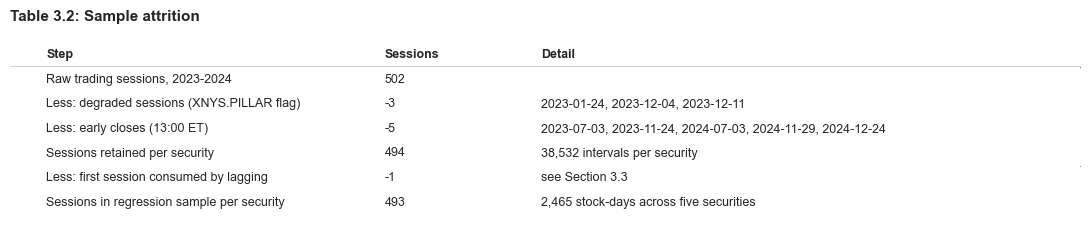

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

attrition = pd.DataFrame([
    ["Raw trading sessions, 2023-2024",              502, ""],
    ["Less: degraded sessions (XNYS.PILLAR flag)",    -3, "2023-01-24, 2023-12-04, 2023-12-11"],
    ["Less: early closes (13:00 ET)",                 -5, "2023-07-03, 2023-11-24, 2024-07-03, 2024-11-29, 2024-12-24"],
    ["Sessions retained per security",                494, "38,532 intervals per security"],
    ["Less: first session consumed by lagging",        -1, "see Section 3.3"],
    ["Sessions in regression sample per security",    493, "2,465 stock-days across five securities"],
], columns=["Step", "Sessions", "Detail"])

print(attrition.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.axis("off")
tbl = ax.table(
    cellText=attrition.values,
    colLabels=attrition.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.34, 0.10, 0.56],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)

for (r, c), cell in tbl.get_celld().items():
    cell.set_linewidth(0)
    if r == 0:
        cell.set_text_props(fontweight="bold")
        cell.visible_edges = "B"
        cell.set_linewidth(1.0)
    elif r in (4, 7):                      # after "retained" and final row
        cell.visible_edges = "B"
        cell.set_linewidth(0.6)
    if r == 7:
        cell.set_text_props(fontweight="bold")

plt.title("Table 3.2: Sample attrition", fontsize=11, fontweight="bold", loc="left", pad=12)
plt.tight_layout()
plt.savefig("figures/table_3_2_attrition.png", dpi=200, bbox_inches="tight")
plt.show()

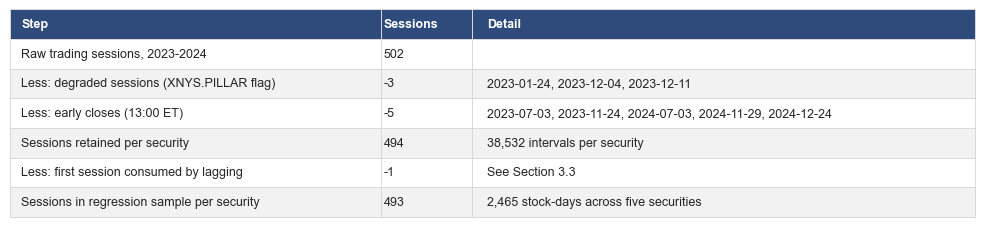

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

attrition = pd.DataFrame([
    ["Raw trading sessions, 2023-2024",             "502", ""],
    ["Less: degraded sessions (XNYS.PILLAR flag)",   "-3", "2023-01-24, 2023-12-04, 2023-12-11"],
    ["Less: early closes (13:00 ET)",                "-5", "2023-07-03, 2023-11-24, 2024-07-03, 2024-11-29, 2024-12-24"],
    ["Sessions retained per security",              "494", "38,532 intervals per security"],
    ["Less: first session consumed by lagging",      "-1", "See Section 3.3"],
    ["Sessions in regression sample per security",  "493", "2,465 stock-days across five securities"],
], columns=["Step", "Sessions", "Detail"])

HEADER_BG, ALT_BG, BORDER = "#2E4B7C", "#F2F2F2", "#D9D9D9"
PADS = [3, 3, 0]   # Step, Sessions, Detail

char_w = [max([len(c) + p] + [len(v) + p for v in attrition[c]])
          for c, p in zip(attrition.columns, PADS)]

# size columns from actual content width
char_w = [max([len(c) + PAD] + [len(v) + PAD for v in attrition[c]]) for c in attrition.columns]
widths = [w / sum(char_w) for w in char_w]

fig, ax = plt.subplots(figsize=(sum(char_w) * 0.085, 2.4))
ax.axis("off")

tbl = ax.table(
    cellText=attrition.values,
    colLabels=attrition.columns,
    cellLoc="left", colLoc="left", loc="center",
    colWidths=widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.9)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(BORDER)
    cell.set_linewidth(0.7)
    cell.PAD = 0.03
    if r == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("white" if r % 2 else ALT_BG)

plt.tight_layout()
plt.savefig("figures/table_3_2_attrition.png", dpi=250, bbox_inches="tight")
plt.show()

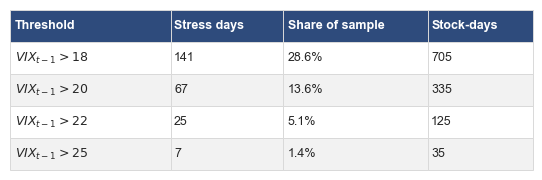

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

THRESHOLDS = [18, 20, 22, 25]

dates_final = panel[["date", "VIX_lag1"]].drop_duplicates("date")
n_total = dates_final["date"].nunique()
n_stocks = panel["stock"].nunique()

rows = []
for t in THRESHOLDS:
    n = dates_final.loc[dates_final["VIX_lag1"] > t, "date"].nunique()
    rows.append([rf"$VIX_{{t-1}} > {t}$", f"{n}", f"{n / n_total:.1%}", f"{n * n_stocks}"])

vix_tbl = pd.DataFrame(rows, columns=["Threshold", "Stress days", "Share of sample", "Stock-days"])

HEADER_BG, ALT_BG, BORDER = "#2E4B7C", "#F2F2F2", "#D9D9D9"
PADS = [4, 3, 3, 3]

char_w = [max([len(c) + p] + [len(str(v)) + p for v in vix_tbl[c]])
          for c, p in zip(vix_tbl.columns, PADS)]
widths = [w / sum(char_w) for w in char_w]

fig, ax = plt.subplots(figsize=(sum(char_w) * 0.085, 1.9))
ax.axis("off")

tbl = ax.table(
    cellText=vix_tbl.values,
    colLabels=vix_tbl.columns,
    cellLoc="left", colLoc="left", loc="center",
    colWidths=widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.9)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(BORDER)
    cell.set_linewidth(0.7)
    cell.PAD = 0.03
    if r == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("white" if r % 2 else ALT_BG)

plt.tight_layout()
plt.savefig("figures/table_3_3_vix_thresholds.png", dpi=250, bbox_inches="tight")
plt.show()

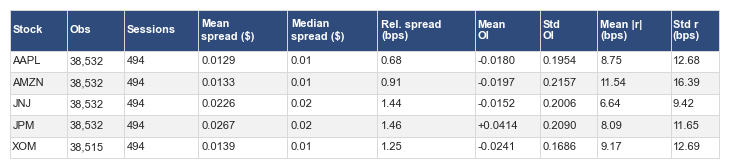

In [36]:
summary_tbl = pd.DataFrame(rows, columns=[
    "Stock", "Obs", "Sessions", "Mean\nspread ($)", "Median\nspread ($)",
    "Rel. spread\n(bps)", "Mean\nOI", "Std\nOI", "Mean |r|\n(bps)", "Std r\n(bps)",
])

HEADER_BG, ALT_BG, BORDER = "#2E4B7C", "#F2F2F2", "#D9D9D9"
PADS = [2] + [1] * 9

def header_width(c):
    return max(len(line) for line in c.split("\n"))

char_w = [max([header_width(c) + p] + [len(str(v)) + p for v in summary_tbl[c]])
          for c, p in zip(summary_tbl.columns, PADS)]
widths = [w / sum(char_w) for w in char_w]

fig, ax = plt.subplots(figsize=(sum(char_w) * 0.085, 1.9))
ax.axis("off")

tbl = ax.table(
    cellText=summary_tbl.values,
    colLabels=summary_tbl.columns,
    cellLoc="left", colLoc="left", loc="center",
    colWidths=widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.7)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(BORDER)
    cell.set_linewidth(0.7)
    cell.PAD = 0.04
    if r == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_height(cell.get_height() * 1.9)
    else:
        cell.set_facecolor("white" if r % 2 else ALT_BG)

plt.tight_layout()
plt.savefig("figures/table_3_4_summary.png", dpi=250, bbox_inches="tight")
plt.show()